In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path
import pickle as pkl

from measurements import get_prev_or_next_frame
from sklearn import preprocessing, model_selection, feature_selection, metrics, inspection, pipeline, ensemble

from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


In [3]:
# Load data
dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/03-31-2025 feature filtered datasets/cell_cycle_aligned/With relative features'
# dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/'
model_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/RF_aligned_delays'

base_str = 'divisions'
suffix = '_feature_filtered.pkl'

basals = pd.read_pickle('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/basals.pkl')
delays = {}
delays[0] = pd.read_pickle(path.join(dataset_dir,f'{base_str}{suffix}'))
for tau in [12,24,36,48,60,72]:
    df = pd.read_pickle(path.join(dataset_dir,f'{base_str}_{tau}h{suffix}'))
    delays[tau] = df.dropna(subset=[('Num daughter differentiated','Meta')])

# censor the 'answers' and other redundant informations
df = delays[0]
features2drop = [(f,a) for f,a in df.columns if 'Time' in f]
features2drop += [(f,a) for f,a in df.columns if 'smoothed' in f and not 'rate' in f]
features2drop += [(f,a) for f,a in df.columns if 'standard' in f and not 'rate' in f]
features2drop += [(f,a) for f,a in df.columns if 'cell coords' in f and not 'rate' in f]
features2drop += [(f,a) for f,a in df.columns if 'duration' in f]
features2drop += [(f,a) for f,a in df.columns if 'Manual' in f]
# features2drop += [(f,a) for f,a in df.columns if '2um' in f]
# features2drop += [(f,a) for f,a in df.columns if '10um' in f]
# features2drop += [(f,a) for f,a in df.columns if '15um' in f]
features2drop += [(f,a) for f,a in df.columns if 'FUCCI' in f]
# features2drop += ['Z']
for tau,df in delays.items():
    delays[tau] = df.drop(columns=features2drop)

# Count data
for tau,df in delays.items():
    print(f'Delay {tau}h, n = {len(df.droplevel(axis=1,level=1).dropna(subset='Num daughter differentiated'))}')

print(delays[0].shape)


Delay 0h, n = 303
Delay 12h, n = 241
Delay 24h, n = 204
Delay 36h, n = 155
Delay 48h, n = 114
Delay 60h, n = 84
Delay 72h, n = 59
(668, 117)


<Axes: xlabel='Mean curvature 10um', ylabel='Axial angle'>

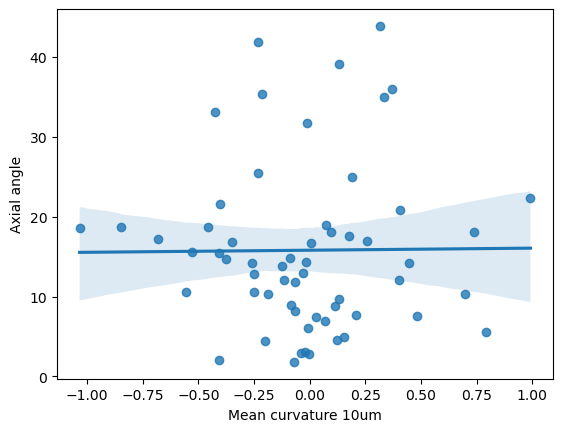

In [4]:
sb.regplot(df.droplevel(axis=1,level=1),x='Mean curvature 10um',y='Axial angle')

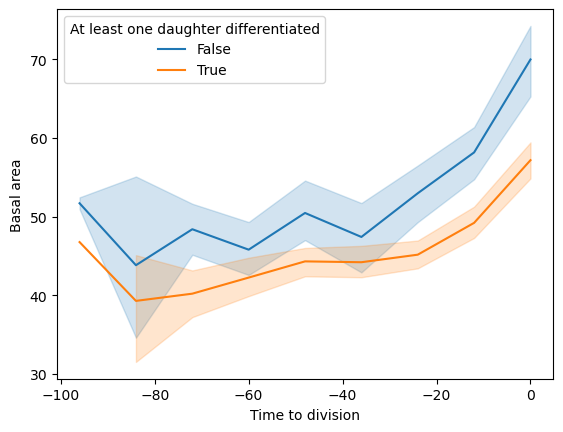

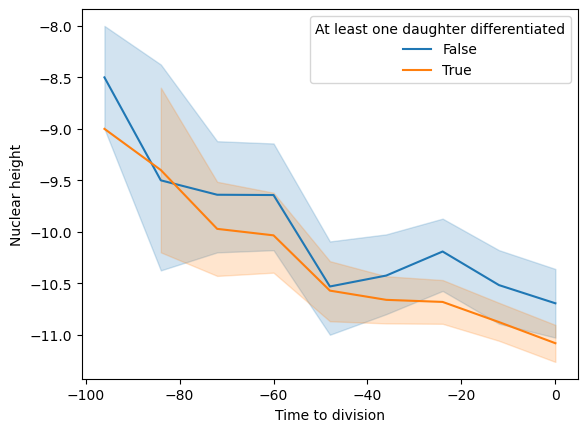

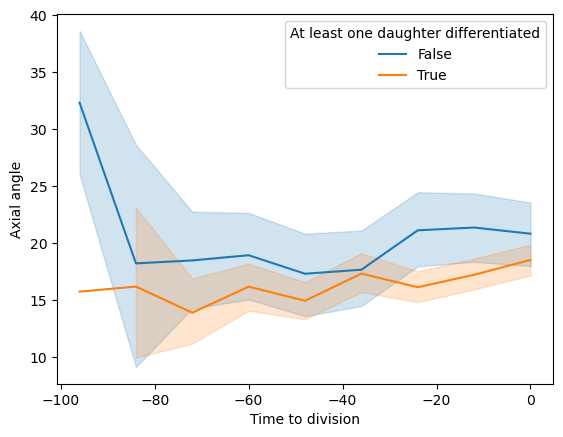

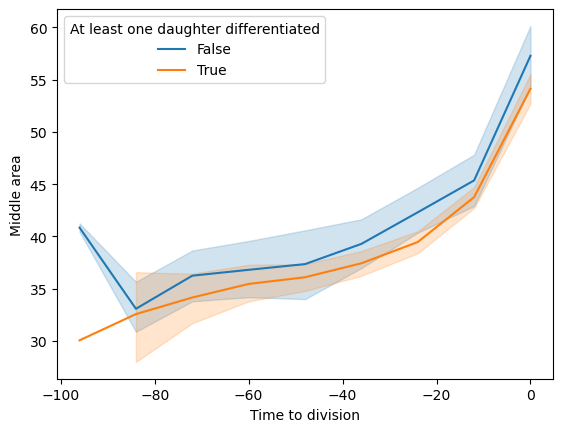

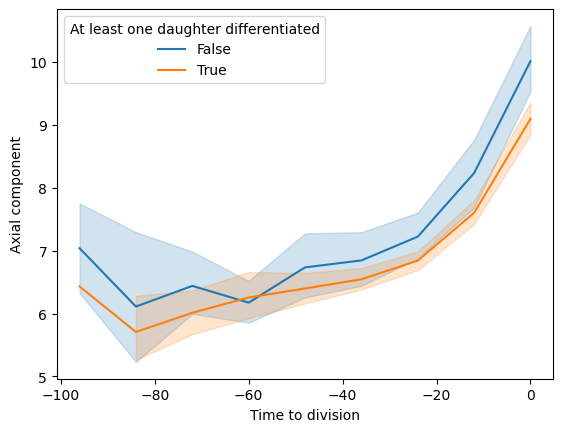

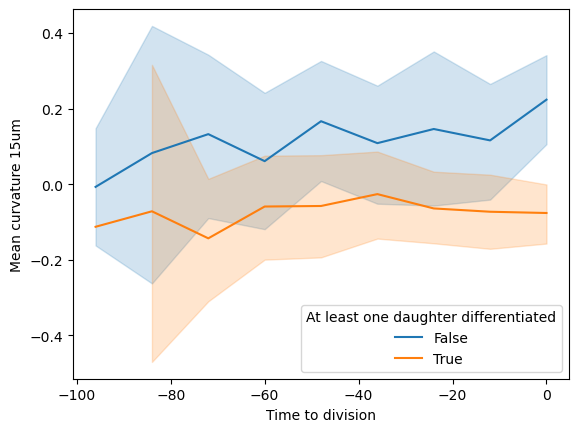

In [7]:
df = basals.dropna(subset=[('Num daughter differentiated','Meta')])

sb.lineplot(df.droplevel(axis=1,level=1),
            x='Time to division',
            y='Basal area',
           hue='At least one daughter differentiated')
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_basal_area.svg')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Time to division',
            y='Nuclear height',
           hue='At least one daughter differentiated')
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_nuc_height.svg')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Time to division',
            y='Axial angle',
           hue='At least one daughter differentiated')
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_nuc_height.svg')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Time to division',
            y='Middle area',
           hue='At least one daughter differentiated')
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_middle_area.svg')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Time to division',
            y='Axial component',
           hue='At least one daughter differentiated')
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_axial_component.svg')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Time to division',
            y='Mean curvature 15um',
           hue='At least one daughter differentiated')

plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Morphology differences/mother_mean_curvature_15um.svg')

<Axes: xlabel='Age', ylabel='Mean curvature 15um'>

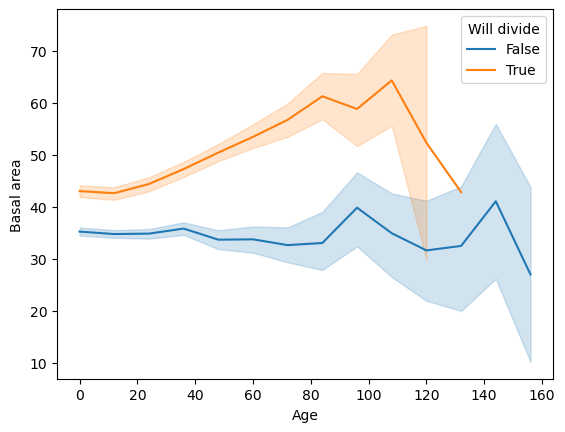

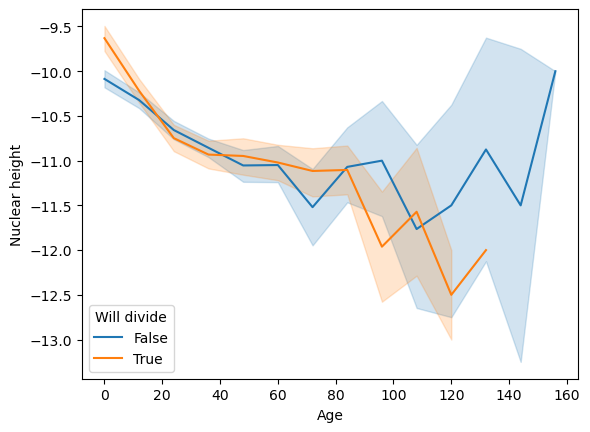

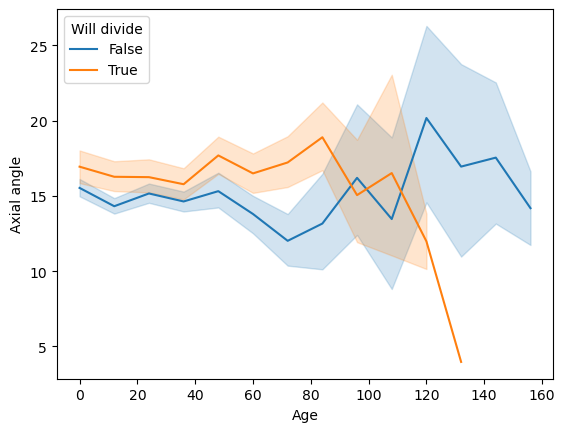

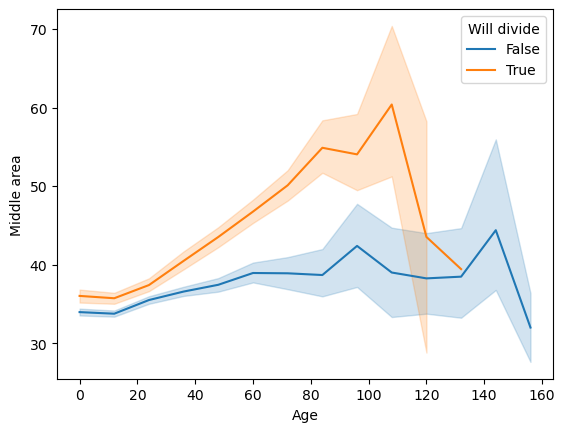

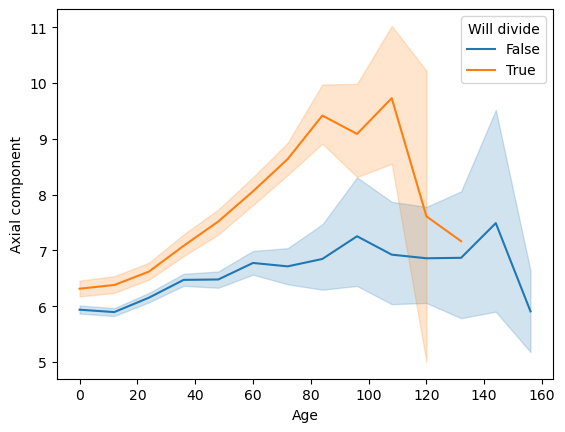

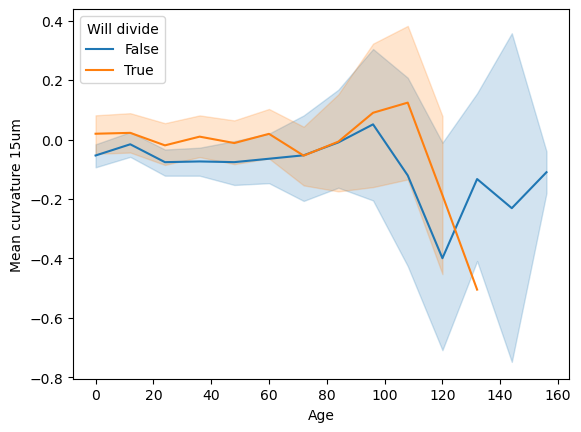

In [55]:
df = basals.dropna(subset=[('Fate known','Meta')])

sb.lineplot(df.droplevel(axis=1,level=1),
            x='Age',
            y='Basal area',
           hue='Will divide')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Age',
            y='Nuclear height',
           hue='Will divide')
# basals['Num daughter differentiated','Meta']

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Age',
            y='Axial angle',
           hue='Will divide')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Age',
            y='Middle area',
           hue='Will divide')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Age',
            y='Axial component',
           hue='Will divide')

plt.figure()
sb.lineplot(df.droplevel(axis=1,level=1),
            x='Age',
            y='Mean curvature 15um',
           hue='Will divide')